# DBSCAN Clustering from Scratch

## Objectives

- Understand Density-Based Spatial Clustering of Applications with Noise.
- Implement DBSCAN using NumPy.
- Identify core, border, and noise points.
- Understand the effect of `eps` and `min_samples`.
- Compare the implementation with Scikit-Learn.

## DBSCAN Intuition

DBSCAN groups points based on density rather than requiring a predefined
number of clusters.

Main concepts:

- `eps`: Maximum distance used to define a neighborhood.
- `min_samples`: Minimum number of points required to form a dense region.
- Core point: Has at least `min_samples` points in its neighborhood.
- Border point: Is close to a core point but does not have enough neighbors.
- Noise point: Does not belong to any cluster.

DBSCAN can discover irregularly shaped clusters and identify noise points.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN

In [3]:
X, _ = make_moons(
    n_samples=400,
    noise=0.08,
    random_state=42
)

df = pd.DataFrame(
    X,
    columns=["Feature_1", "Feature_2"]
)

df.head()

,Feature_1,Feature_2
0,-0.033226,0.420541
1,0.693183,-0.411493
2,0.836026,0.532761
3,0.145537,0.283647
4,0.093859,0.955842


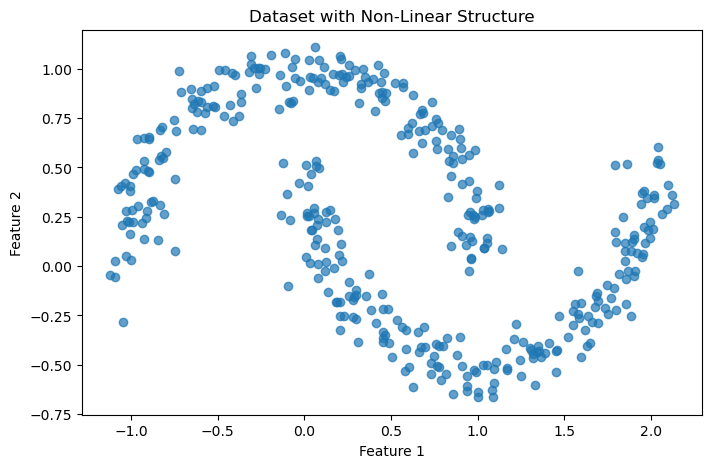

In [4]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    alpha=0.7
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Dataset with Non-Linear Structure")

plt.show()

In [5]:
class DBSCANScratch:

    def __init__(self, eps=0.2, min_samples=5):
        self.eps = eps
        self.min_samples = min_samples
        self.labels_ = None

    def _get_neighbors(self, X, point_index):
        distances = np.sqrt(
            np.sum(
                (X - X[point_index]) ** 2,
                axis=1
            )
        )

        return np.where(distances <= self.eps)[0]

    def fit(self, X):
        X = np.asarray(X)

        n_samples = len(X)

        labels = np.full(
            n_samples,
            -1,
            dtype=int
        )

        visited = np.zeros(
            n_samples,
            dtype=bool
        )

        cluster_id = 0

        for point in range(n_samples):

            if visited[point]:
                continue

            visited[point] = True

            neighbors = self._get_neighbors(
                X,
                point
            )

            if len(neighbors) < self.min_samples:
                labels[point] = -1
                continue

            labels[point] = cluster_id

            seeds = list(neighbors)

            i = 0

            while i < len(seeds):

                current = seeds[i]

                if not visited[current]:

                    visited[current] = True

                    current_neighbors = self._get_neighbors(
                        X,
                        current
                    )

                    if len(current_neighbors) >= self.min_samples:

                        for neighbor in current_neighbors:

                            if neighbor not in seeds:
                                seeds.append(neighbor)

                if labels[current] == -1:
                    labels[current] = cluster_id

                i += 1

            cluster_id += 1

        self.labels_ = labels

        return self

    def predict(self, X):
        return self.labels_